In [1]:
from TKA_JGA_Mo_250111_1 import calc_eq, dfg, phi_Soave, delta_f_G
import numpy as np
import matplotlib.pyplot as plt

phi [0.94560396 1.26979011 0.66073691 1.20631367 0.73471606 0.62239004
 1.21570881]


## Alvarez 2017: here also these jumps seeable

In [2]:
T = np.linspace(150, 400, 50) + 273.15
p = np.array(([10, 30, 50, 100])) * 1e5
x_0 = np.array([
    0.25, # CO2
    0.75-5e-20, # H2
    1e-20, # H2O
    1e-20,
    1e-20, #set one off if methanol synthesis is checked
    1e-20,
    1e-20
])

In [3]:
counter = 0
x_eq = np.zeros((len(p), len(T), len(x_0)))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
S_DME = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0, 'real gas')
        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]
        S_MeOH[i, j] = - (x_0[5] - n_eq_val[5]) / (x_0[0] - n_eq_val[0])
        S_DME[i, j] = - (2 * x_0[4] - 2 * n_eq_val[4]) / (x_0[0] - n_eq_val[0])

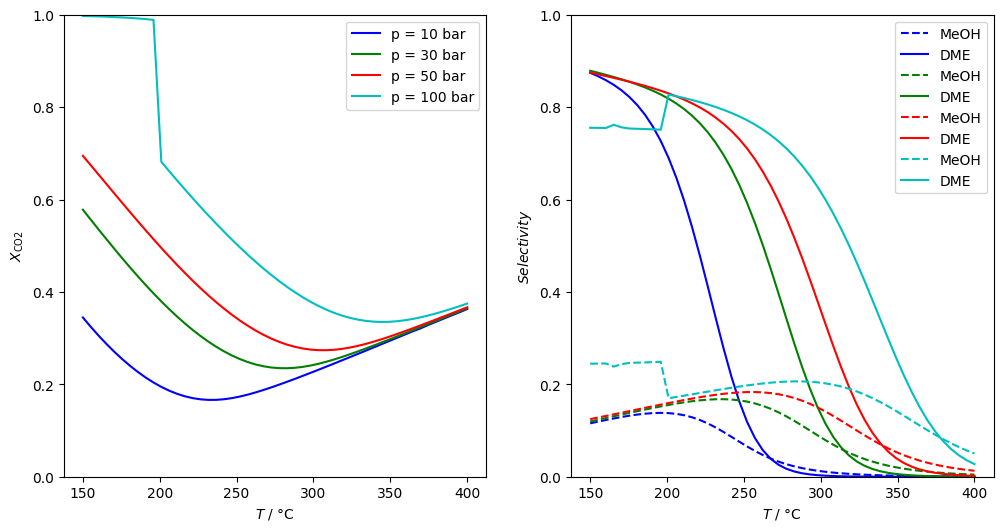

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


species = ['CO2', 'H2', 'H2O', 'CO', 'DME', 'MeOH', 'N2']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

for j in range(len(p)):
    #plt.plot(T-273.15, x_eq[0, :, j], label=species[j], color=colors[j])
    # plot X_CO2
    ax[0].plot(T-273.15, X_CO2[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])
    # plot S_MeOH
    ax[1].plot(T-273.15, S_MeOH[j, :], label='MeOH', color=colors[j], linestyle='--')
    ax[1].plot(T-273.15, S_DME[j, :], label='DME', color=colors[j], linestyle='-')

ax[0].set_xlabel(r'$T$ / °C')
ax[1].set_xlabel(r'$T$ / °C')
ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)
ax[0].set_ylabel(r'$X_{\mathrm{CO2}}$')
ax[1].set_ylabel(r'$Selectivity$')
ax[0].legend()
ax[1].legend()
plt.show()